# 01 — Dataset Overview

First-look comprehensive overview of the RADS dataset.

**Analyzer:** `OverviewAnalyzer`  
**Outputs:** `dataset_overview_report.md`, `summary.json`, `column_completeness.csv`, `dataset_summary.csv`

## Setup

In [1]:
import sys
import time
from pathlib import Path

# Ensure project root is on path
PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

NOTEBOOK_NAME = "01_dataset_overview"
START_TIME = time.time()

In [2]:
from eda.utils.config import load_config
from eda.utils.logger import EDALogger
from eda.utils.metadata_loader import MetadataLoader
from eda.utils.wandb_manager import WandbManager
from eda.utils.plotting import PlotEngine 
from eda.utils.report_generator import ReportGenerator
from eda.utils.system_monitor import SystemMonitor
from eda.utils.output_manager import OutputManager
from eda.utils.statistics import OverviewAnalyzer

import pandas as pd
import matplotlib.pyplot as plt

# Load config and initialise
config = load_config()
logger = EDALogger.setup(config, NOTEBOOK_NAME)
monitor = SystemMonitor()
plot_engine = PlotEngine(dpi=config.figure_dpi, formats=config.figure_formats)
output = OutputManager(config, NOTEBOOK_NAME)

# System snapshot (start)
snap_start = monitor.snapshot("start")
logger.log_start()

[14:16:55] INFO     ═══ EDA START: 01_dataset_overview ═══ | EDA v1.0.0 | Python 3.13.2 | Windows


In [3]:
# W&B initialisation
loader = MetadataLoader(config)
df = loader.load()
metadata_hash = loader.metadata_hash
git_commit = EDALogger.get_git_commit()

wb = WandbManager(config, NOTEBOOK_NAME)
wb.init(metadata_hash=metadata_hash, git_commit=git_commit)
wb.log_system_info(snap_start)

logger.log_data_loaded(df.shape[0], df.shape[1], metadata_hash)
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Metadata hash: {metadata_hash}")

Preprocessing: Completely empty columns: ['duplicate_group_id']


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Amita nagar\_netrc.


wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


wandb: setting up run u8drhrk5


...

wandb: Syncing run eda-01_dataset_overview


wandb:  View project at https://wandb.ai/saksham4data-vinkura/RADS


wandb:  View run at https://wandb.ai/saksham4data-vinkura/RADS/runs/u8drhrk5


[14:17:13] INFO     Data loaded: 5338 rows × 51 columns | hash=sha256:a761cf722...


Loaded: 5,338 rows × 51 columns
Metadata hash: sha256:a761cf7228fb39da4ebb18fc1645dcf604229f53a651c8f0eb858d5575f7213a


## Analysis

In [4]:
# Run the OverviewAnalyzer
analyzer = OverviewAnalyzer(df, config)
results = analyzer.analyze()

# Display key results
dims = results["dimensions"]
print(f"Rows: {dims['rows']:,}")
print(f"Columns: {dims['columns']}")
print(f"\nDtype breakdown: {dims['dtypes']}")

print("\n── Per-Dataset Counts ──")
for ds in results["per_dataset_counts"]:
    print(f"  {ds['dataset']}: {ds['count']:,} ({ds['percentage']:.1f}%)")

print(f"\n── Media Types ──")
print(f"  {results['media_types']['distribution']}")

print(f"\n── Duplicates ──")
dups = results["duplicates"]
print(f"  Flagged: {dups.get('flagged_duplicates', 'N/A')}")
print(f"  Exact row duplicates: {dups['exact_row_duplicates']}")

print(f"\n── Memory ──")
print(f"  {results['memory_footprint']['total_mb']:.1f} MB")

Rows: 5,338
Columns: 51

Dtype breakdown: {'float64': 18, 'object': 12, 'int64': 3, 'category': 1}

── Per-Dataset Counts ──
  picek: 4,238 (79.4%)
  kaggle: 989 (18.5%)
  tudat: 111 (2.1%)

── Media Types ──
  {'nan': 4238, 'image': 989, 'video': 111}

── Duplicates ──
  Flagged: 0
  Exact row duplicates: 0

── Memory ──
  4.6 MB


## Visualisation

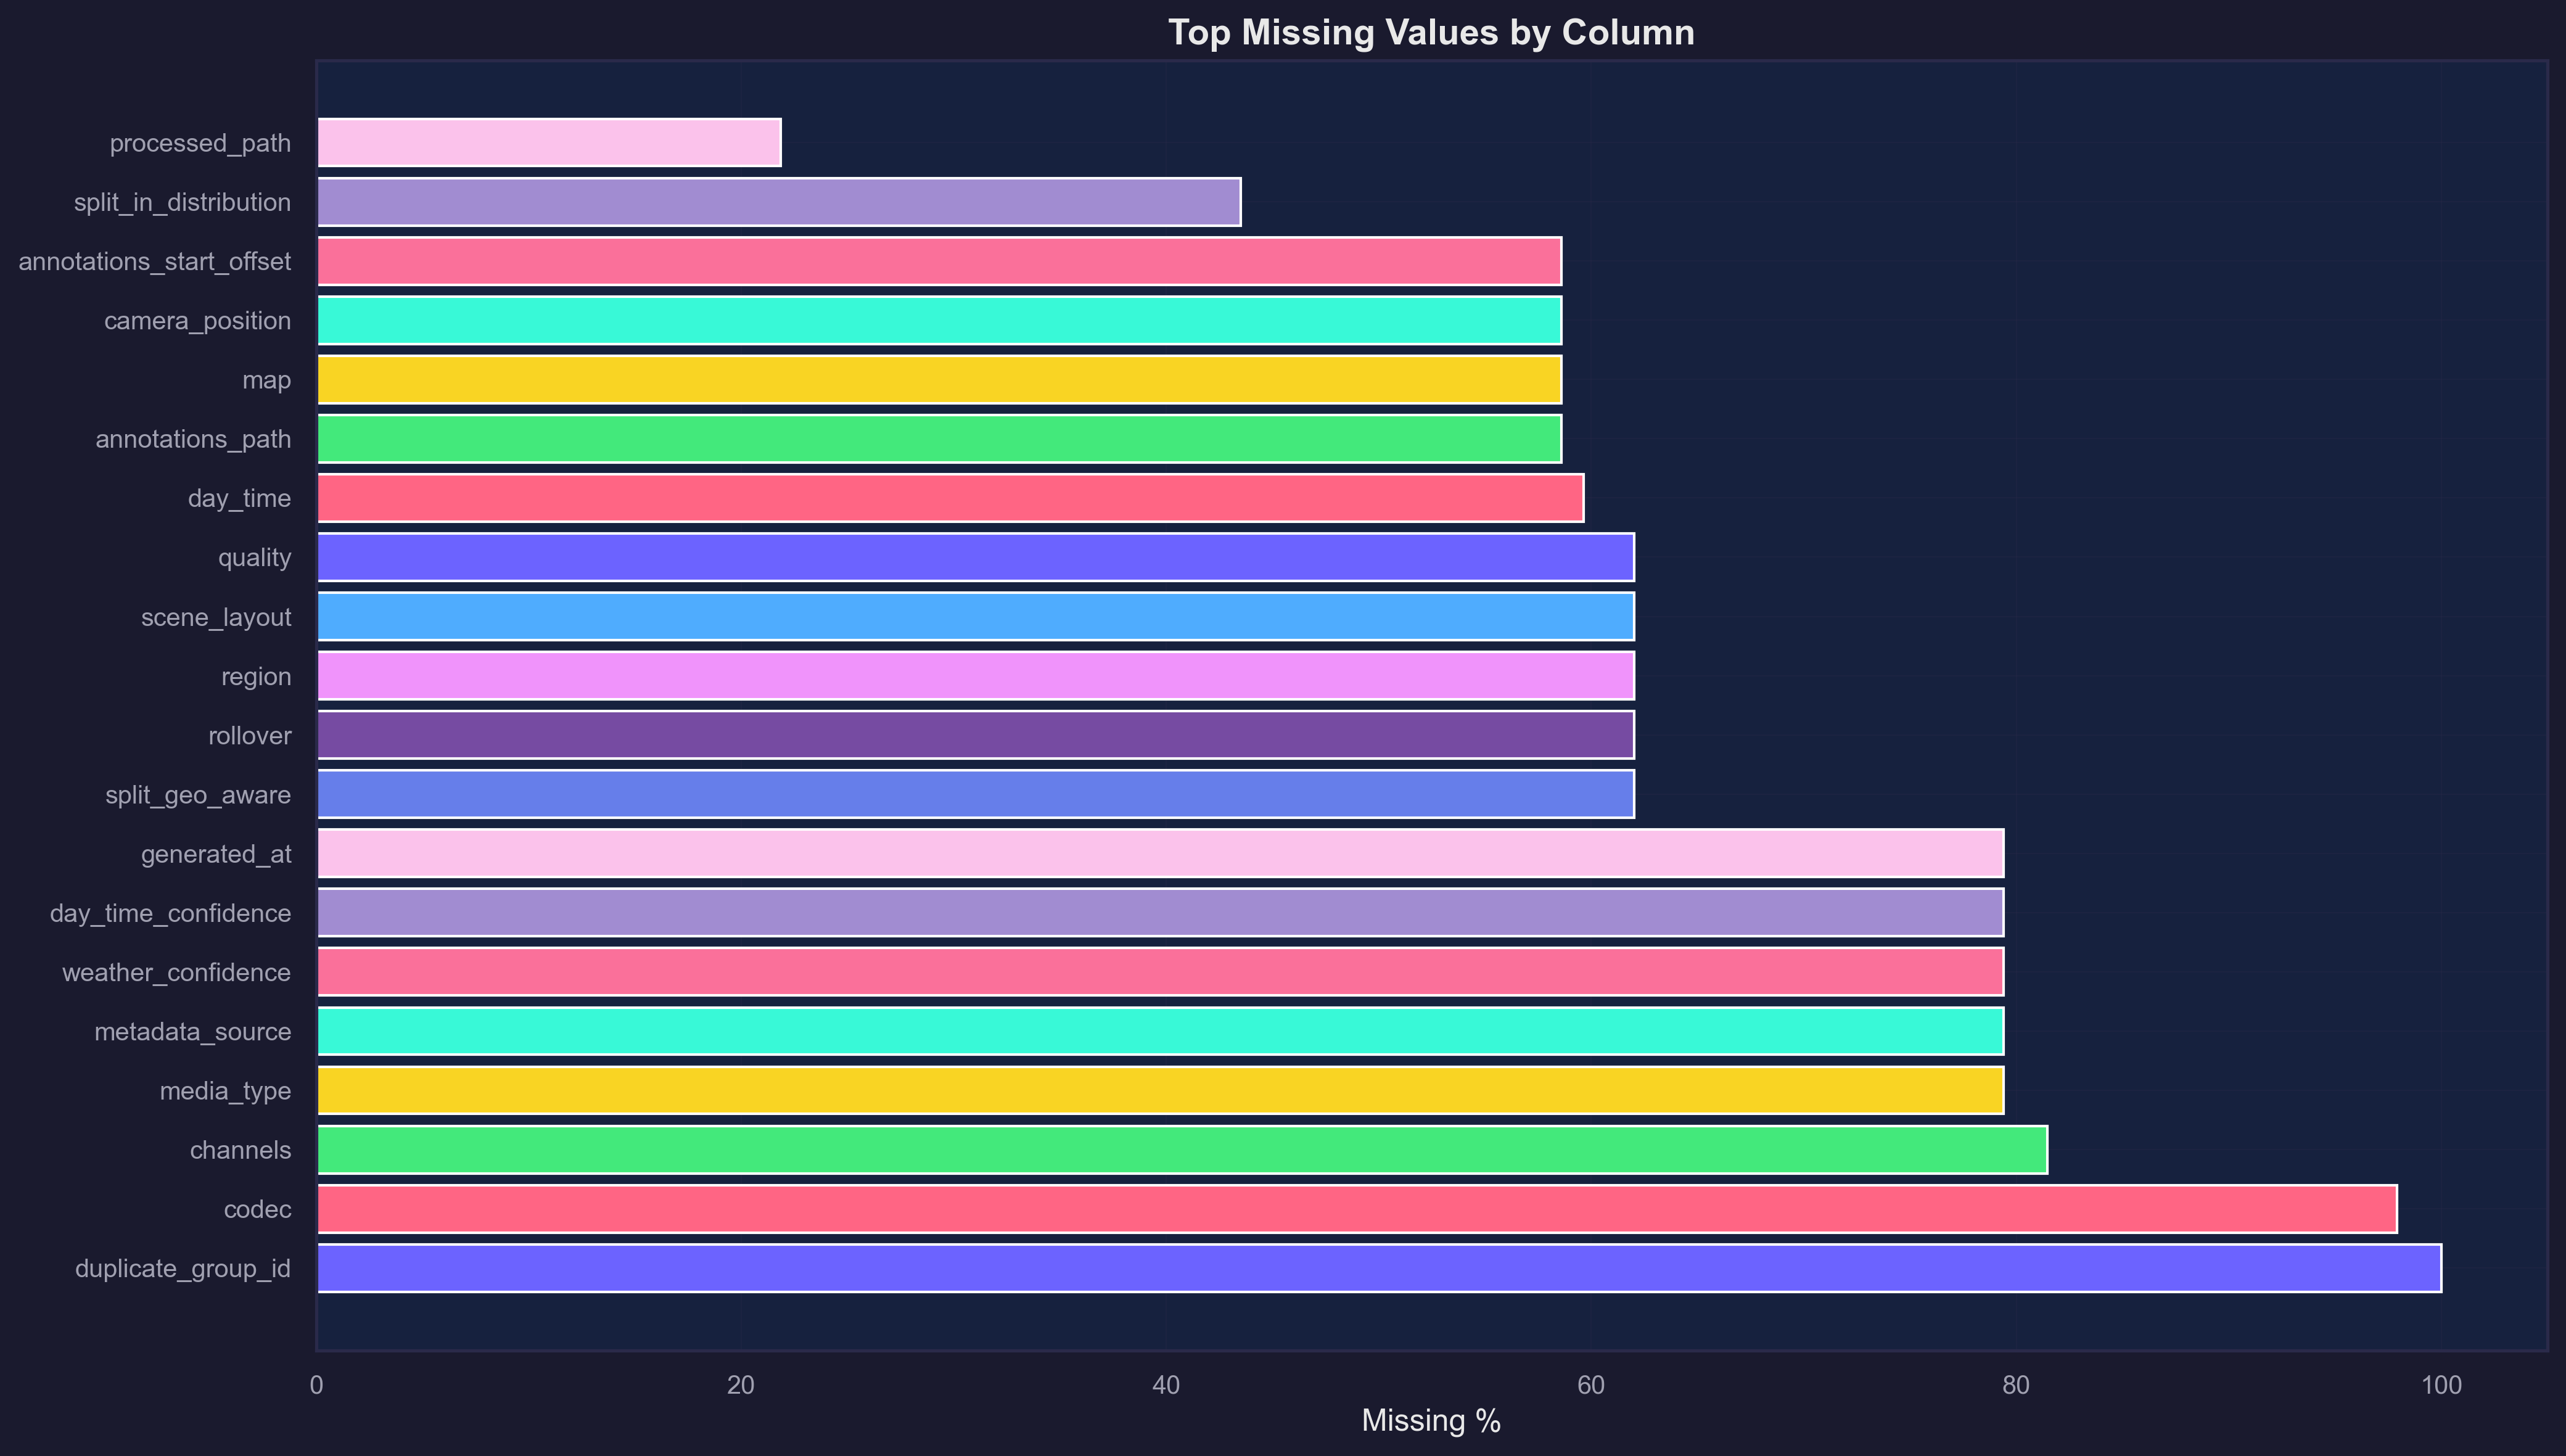

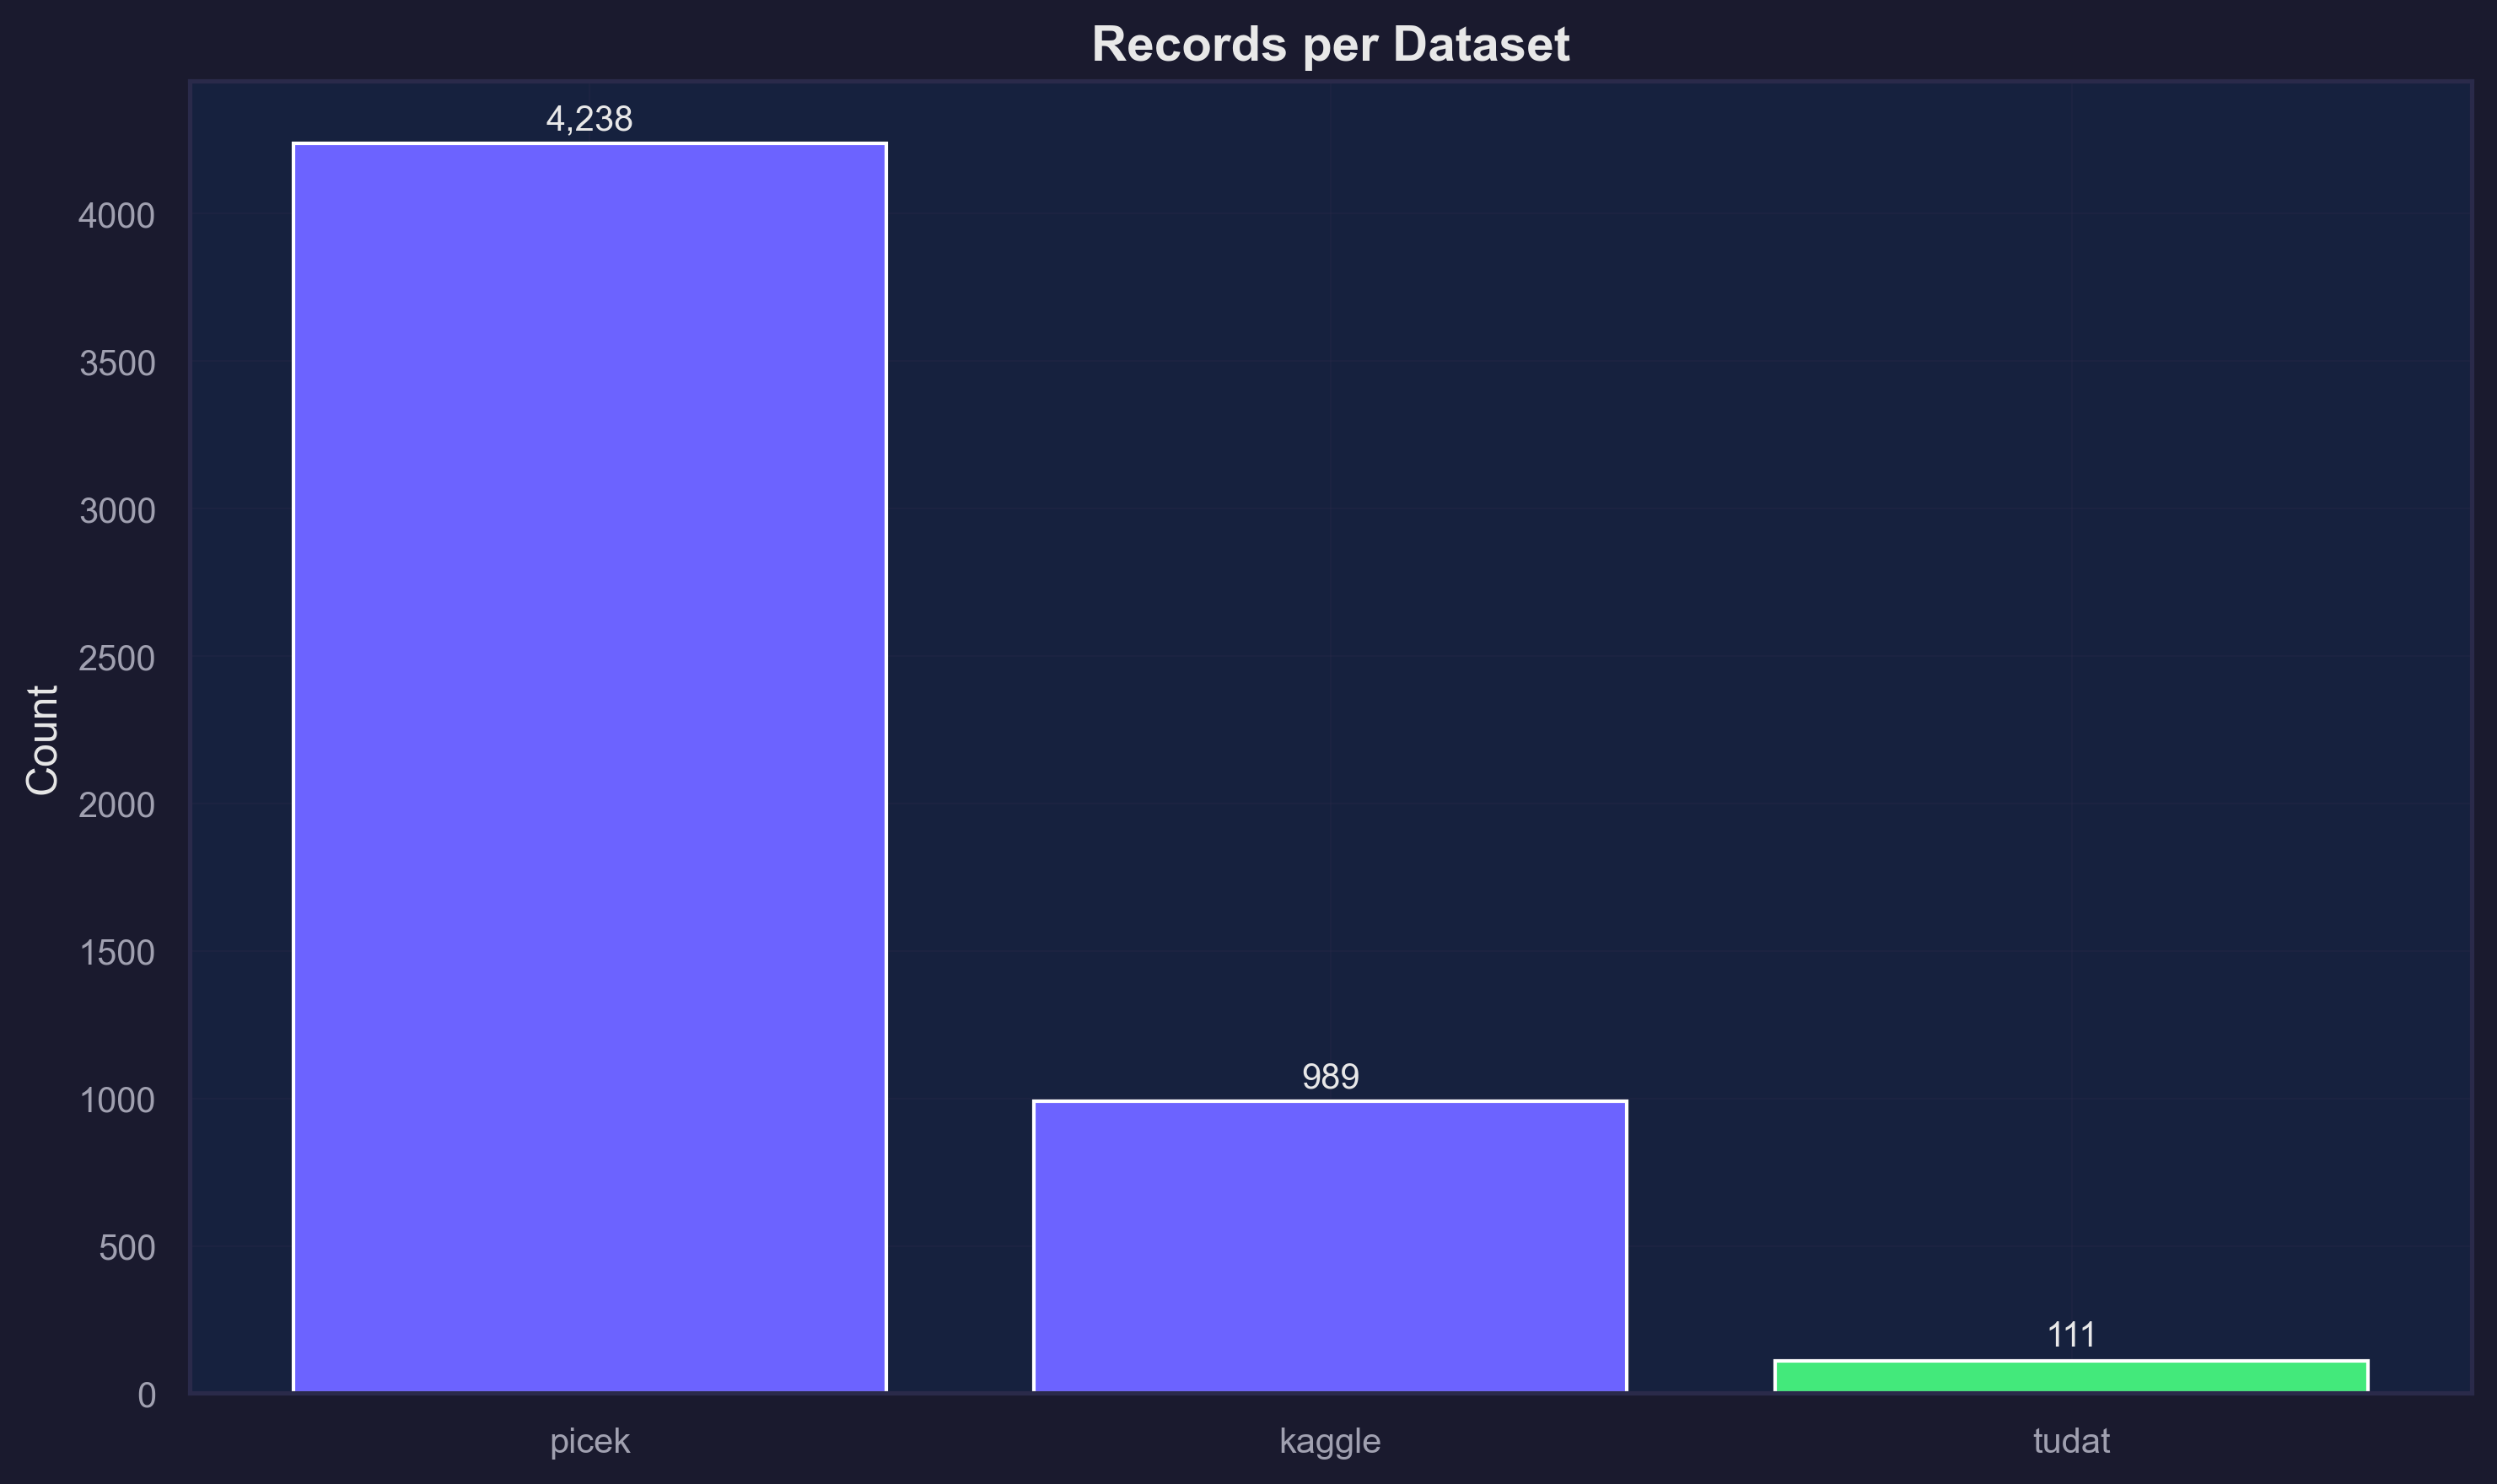

In [5]:
# Missing values heatmap
missing_df = pd.DataFrame(results["missing_values"])
top_missing = missing_df[missing_df["missing_count"] > 0].head(20)
from eda.utils.plotting import CATEGORICAL_COLOURS
if not top_missing.empty:
    fig, ax = plot_engine.create_figure(figsize=(14, 8))
    ax.barh(
        top_missing["column"],
        top_missing["missing_percent"],
        color=CATEGORICAL_COLOURS[:len(top_missing)],
    )
    ax.set_xlabel("Missing %")
    ax.set_title("Top Missing Values by Column", fontweight="bold")
    plt.tight_layout()
    output.save_figure(fig, "missing_values")
    wb.log_figure(fig, "missing_values", caption="Missing values by column")
    plt.show()
else:
    print("No missing values found!")

# Per-dataset distribution
fig, ax = plot_engine.create_figure(figsize=(10, 6))
ds_counts = pd.DataFrame(results["per_dataset_counts"])
from eda.utils.plotting import DATASET_COLOURS
colors = [DATASET_COLOURS.get(n, "#6C63FF") for n in ds_counts["dataset"]]
ax.bar(ds_counts["dataset"], ds_counts["count"], color=colors)
ax.set_title("Records per Dataset", fontweight="bold")
ax.set_ylabel("Count")
for i, row in ds_counts.iterrows():
    ax.text(i, row["count"] + 50, f"{row['count']:,}", ha="center", fontsize=10)
plt.tight_layout()
output.save_figure(fig, "per_dataset_counts")
wb.log_figure(fig, "per_dataset_counts", caption="Records per dataset")
plt.show()

## Report & Export

In [6]:
# Build report
rg = ReportGenerator(
    NOTEBOOK_NAME,
    eda_version=config.eda_version,
    dataset_version=loader.dataset_version,
    metadata_hash=metadata_hash,
    git_commit=git_commit,
    seed=config.seed,
)
rg.add_heading("Dataset Dimensions")
rg.add_key_value_list({
    "Total Rows": f"{dims['rows']:,}",
    "Total Columns": dims["columns"],
    "Memory Footprint": f"{results['memory_footprint']['total_mb']:.1f} MB",
})
rg.add_heading("Per-Dataset Counts")
rg.add_table(ds_counts, key="per_dataset_counts")
rg.add_heading("Missing Values")
rg.add_table(missing_df.head(20), key="missing_values")
rg.add_stats({
    "total_rows": dims["rows"],
    "total_columns": dims["columns"],
    "datasets": len(results["per_dataset_counts"]),
    "exact_duplicates": dups["exact_row_duplicates"],
    "memory_mb": results["memory_footprint"]["total_mb"],
    "missing_values_score": results["quality_components"]["missing_values_score"],
    "duplicate_score": results["quality_components"]["duplicate_score"],
})

# Save reports
output.save_report(rg.build_markdown(), "dataset_overview_report")
output.save_summary_json(rg.build_summary_json(), "summary")

# Save CSV exports
output.save_csv(missing_df, "column_completeness")
output.save_csv(ds_counts, "dataset_summary")

# Log W&B table and stats
wb.log_stats({
    "overview/total_rows": dims["rows"],
    "overview/total_columns": dims["columns"],
    "overview/datasets": len(results["per_dataset_counts"]),
    "overview/exact_duplicates": dups["exact_row_duplicates"],
    "overview/missing_values_score": results["quality_components"]["missing_values_score"],
    "overview/duplicate_score": results["quality_components"]["duplicate_score"],
})
wb.log_table(ds_counts, "per_dataset_counts")

print("Reports and exports saved.")

Reports and exports saved.


## Teardown

In [7]:
# System snapshot (end)
snap_end = monitor.snapshot("end")
delta = monitor.compute_delta(snap_start, snap_end)
duration = time.time() - START_TIME

# Log system info to W&B
wb.log_system_info(snap_end)
wb.log_stats({"execution/duration_seconds": round(duration, 2)})

# Upload all outputs as W&B Artifact
wb.log_notebook_outputs(
    output.figures_dir,
    output.reports_dir,
    output.exports_dir,
    metadata={"notebook": NOTEBOOK_NAME, "duration": round(duration, 2)},
)

# Finalise outputs (manifest, latest, run_history)
manifest = output.finalize(
    wandb_run_id=wb.run_id,
    wandb_run_url=wb.run_url,
    git_commit=git_commit,
    metadata_hash=metadata_hash,
    rows_analyzed=df.shape[0],
    duration_seconds=duration,
)

# Log execution summary
logger.log_execution_summary(
    duration_seconds=duration,
    files_exported=output.all_exported_files,
    wandb_run_id=wb.run_id,
    wandb_run_url=wb.run_url,
    stats_generated=["dimensions", "per_dataset_counts", "missing_values", "duplicates"],
)

# Finish W&B
wb.finish()

print(f"\n✅ Notebook complete in {duration:.1f}s")
print(f"   Exported {len(output.all_exported_files)} files")
print(f"   W&B Run: {wb.run_url or 'N/A'}")

wandb: Adding directory to artifact (E:\Rads\eda\figures\2026-08-03_08-46)... 

Done. 0.1s


wandb: Adding directory to artifact (E:\Rads\eda\reports\2026-08-03_08-46)... 

Done. 0.0s


wandb: Adding directory to artifact (E:\Rads\eda\exports\2026-08-03_08-46)... 

...

wandb: uploading data


wandb: 
wandb: Run history:
wandb:    execution/duration_seconds ▁
wandb:             overview/datasets ▁
wandb:      overview/duplicate_score ▁
wandb:     overview/exact_duplicates ▁
wandb: overview/missing_values_score ▁
wandb:        overview/total_columns ▁
wandb:           overview/total_rows ▁
wandb:              system/cpu/cores ▁▁
wandb:            system/cpu/percent ▁█
wandb:           system/disk/percent ▁▁
wandb:                            +4 ...
wandb: 
wandb: Run summary:
wandb:    execution/duration_seconds 55
wandb:             overview/datasets 3
wandb:      overview/duplicate_score 1
wandb:     overview/exact_duplicates 0
wandb: overview/missing_values_score 0.64554
wandb:        overview/total_columns 51
wandb:           overview/total_rows 5338
wandb:              system/cpu/cores 4
wandb:            system/cpu/percent 36.9
wandb:           system/disk/percent 68.5
wandb:                            +4 ...
wandb: 


wandb:  View run eda-01_dataset_overview at: https://wandb.ai/saksham4data-vinkura/RADS/runs/u8drhrk5
wandb:  View project at: https://wandb.ai/saksham4data-vinkura/RADS
wandb: Synced 5 W&B file(s), 3 media file(s), 8 artifact file(s) and 0 other file(s)


wandb: Find logs at: .\wandb\run-20260803_141704-u8drhrk5\logs



✅ Notebook complete in 55.0s
   Exported 8 files
   W&B Run: N/A
